# Time-Dependent Travel Times (TDVRP)

Reality: a 10-km drive at 9am isn't a 10-km drive at 5pm. Rush hour can double the time. Lunch is light. So far our models have assumed a *single* travel-time matrix, which structurally cannot express "this arc takes 12 min in the morning and 22 min in the evening."

## Why this is awkward in OR-Tools

The natural thing to want is a transit callback that knows *what time it is when this arc is traversed*. OR-Tools transit callbacks are stateless — they get `(from_index, to_index)` and nothing else. There is no "current cumul" handed in. So we can't write the function we want.

Three workarounds exist (the time-expanded graph, an end-of-day soft penalty, and **shift-copy vehicles**). We're doing shift-copy vehicles here — the most commonly-used pattern in production code.

## The shift-copy idea

Split the day into K time-of-day *shifts*: morning, midday, afternoon. Represent each shift as its own "vehicle" with:

- Its own travel-time matrix (morning = 1.0×, midday = 0.85×, afternoon-rush = 1.5×)
- Its own arc-cost evaluator (so the objective sees the right cost for each shift)
- A `Time` dimension Start/End constrained to its shift window

OR-Tools supports this via `AddDimensionWithVehicleTransits` (one transit callback per vehicle) and `SetArcCostEvaluatorOfVehicle` (one cost callback per vehicle). The solver then *picks which shift each customer goes in* by routing them through the appropriate "vehicle."

Limitation worth being honest about: a single physical truck can't be modelled as "start in the morning shift and keep going into the afternoon shift with travel times that rise as you go." Each shift-vehicle is sealed into its window. If you need a single truck spanning shifts with continuously-varying travel times, you need the time-expanded graph approach instead.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

random.seed(11)
np.random.seed(11)

## 1. Instance

- 12 customers in a 60×60 km area, depot in the centre.
- Working day: minute 0 = 8am, minute 600 = 6pm.
- Three shifts: morning `[0, 240]` (8am–12pm), midday `[240, 420]` (12pm–3pm), afternoon `[420, 600]` (3pm–6pm).
- Customer windows are mostly *flexible* (open most of the day) so the solver has freedom to schedule.
- Travel-time multipliers per shift: `{morning: 1.0, midday: 0.85, afternoon: 1.5}`.
- Cost equals travel time in minutes — so the solver naturally prefers off-peak shifts.

In [2]:
N_CUSTOMERS = 12
DEPOT = 0
SERVICE_TIME = 10

SHIFTS = [
    {"name": "morning",   "window": (0, 240),   "multiplier": 1.0},
    {"name": "midday",    "window": (240, 420), "multiplier": 0.85},
    {"name": "afternoon", "window": (420, 600), "multiplier": 1.5},
]
HORIZON = 600

points = [(30.0, 30.0)] + [
    (random.uniform(0, 60), random.uniform(0, 60)) for _ in range(N_CUSTOMERS)
]
demands = [0] + [random.randint(2, 8) for _ in range(N_CUSTOMERS)]

def base_distance(pts):
    n = len(pts)
    m = [[0.0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i != j:
                m[i][j] = math.hypot(xi - xj, yi - yj)
    return m

base = base_distance(points)

# Per-shift integer travel-time matrices: base distance * multiplier, rounded.
shift_travel = []
for s in SHIFTS:
    n = len(points)
    m = [[int(round(base[i][j] * s["multiplier"])) for j in range(n)] for i in range(n)]
    shift_travel.append(m)

# Most customers have a wide window (open all day). A few have a tight window
# that forces a specific shift.
windows = [(0, HORIZON)]
for i in range(1, N_CUSTOMERS + 1):
    if i % 6 == 0:
        windows.append((0, 240))      # must be morning
    elif i % 6 == 3:
        windows.append((420, 600))    # must be afternoon
    else:
        windows.append((0, 600))      # any shift

for i in range(1, len(points)):
    print(f"  c{i}: pos=({points[i][0]:5.1f},{points[i][1]:5.1f})  demand={demands[i]}  window={windows[i]}")

  c1: pos=( 27.1, 33.6)  demand=3  window=(0, 600)
  c2: pos=( 55.5, 27.9)  demand=3  window=(0, 600)
  c3: pos=( 30.5, 35.2)  demand=6  window=(420, 600)
  c4: pos=( 11.1, 30.7)  demand=2  window=(0, 600)
  c5: pos=( 37.8, 47.6)  demand=8  window=(0, 600)
  c6: pos=(  5.6, 18.2)  demand=5  window=(0, 240)
  c7: pos=(  5.4, 48.6)  demand=4  window=(0, 600)
  c8: pos=( 41.6,  2.5)  demand=5  window=(0, 600)
  c9: pos=( 58.9, 57.9)  demand=6  window=(420, 600)
  c10: pos=( 39.2, 36.9)  demand=8  window=(0, 600)
  c11: pos=(  9.4,  0.9)  demand=3  window=(0, 600)
  c12: pos=( 31.7,  3.6)  demand=6  window=(0, 240)


## 2. Model — one vehicle per shift

Each shift becomes one vehicle. We register K transit callbacks (one per shift's matrix) and pass them to `AddDimensionWithVehicleTransits`. We also register K cost callbacks and bind each to its vehicle via `SetArcCostEvaluatorOfVehicle`. Finally, we constrain each vehicle's Start CumulVar to its shift's window so the solver knows which shift each vehicle belongs to.

In [3]:
def solve_tdvrp(shift_travel, shifts, demands, time_windows,
                vehicle_capacity, service_time, horizon,
                depot=0, time_limit=5):
    n = len(shift_travel[0])
    num_vehicles = len(shifts)
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    transit_cb_indices = []
    cost_cb_indices = []
    for v in range(num_vehicles):
        tt = shift_travel[v]
        def make_time_cb(matrix):
            def cb(fi, ti):
                fn, tn = manager.IndexToNode(fi), manager.IndexToNode(ti)
                st = 0 if fn == depot else service_time
                return st + matrix[fn][tn]
            return cb
        def make_cost_cb(matrix):
            def cb(fi, ti):
                fn, tn = manager.IndexToNode(fi), manager.IndexToNode(ti)
                return matrix[fn][tn]
            return cb
        transit_cb_indices.append(
            routing.RegisterTransitCallback(make_time_cb(tt))
        )
        cost_cb_indices.append(
            routing.RegisterTransitCallback(make_cost_cb(tt))
        )

    for v in range(num_vehicles):
        routing.SetArcCostEvaluatorOfVehicle(cost_cb_indices[v], v)

    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]
    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        demand_idx, 0, [vehicle_capacity] * num_vehicles, True, "Capacity",
    )

    routing.AddDimensionWithVehicleTransits(
        transit_cb_indices, 60, horizon, False, "Time",
    )
    time_dim = routing.GetDimensionOrDie("Time")

    for node in range(n):
        if node == depot:
            continue
        a, b = time_windows[node]
        time_dim.CumulVar(manager.NodeToIndex(node)).SetRange(int(a), int(b))

    for v, shift in enumerate(shifts):
        lo, hi = shift["window"]
        time_dim.CumulVar(routing.Start(v)).SetRange(int(lo), int(hi))
        time_dim.CumulVar(routing.End(v)).SetRange(int(lo), int(hi))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.Start(v)))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.End(v)))

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)

    sol = routing.SolveWithParameters(params)
    if sol is None:
        return None

    routes = []
    arrivals = {}
    total_cost = 0
    for v in range(num_vehicles):
        idx = routing.Start(v)
        route = []
        while not routing.IsEnd(idx):
            node = manager.IndexToNode(idx)
            route.append(node)
            arrivals[node] = sol.Min(time_dim.CumulVar(idx))
            prev = idx
            idx = sol.Value(routing.NextVar(idx))
            total_cost += routing.GetArcCostForVehicle(prev, idx, v)
        route.append(manager.IndexToNode(idx))
        routes.append(route)
    return {"routes": routes, "arrivals": arrivals, "objective": sol.ObjectiveValue(),
            "total_cost": total_cost, "status": routing.status()}

In [4]:
result = solve_tdvrp(
    shift_travel, SHIFTS, demands, windows,
    vehicle_capacity=25, service_time=SERVICE_TIME, horizon=HORIZON,
    time_limit=5,
)
print(f"status: {result['status']}, objective: {result['objective']}")
for v, (route, shift) in enumerate(zip(result["routes"], SHIFTS)):
    inner = [n for n in route if n != DEPOT]
    print(f"  {shift['name']:<10} {shift['window']}  customers: {inner}")

status: 1, objective: 322
  morning    (0, 240)  customers: [8, 12, 11, 6, 4, 7]
  midday     (240, 420)  customers: [1, 10, 2]
  afternoon  (420, 600)  customers: [9, 5, 3]


## 3. Naive single-matrix baseline\n\nWhat happens if you ignore traffic and plan with the *average* travel-time matrix? Two failure modes:\n\n1. **Hidden cost**: the model says \"this route takes 300 min and costs C.\" Reality routes the arcs through whatever shift each one lands in, and the realised number is different.\n2. **Hidden infeasibility**: the plan claims to finish in the day, but routes that land in rush hour actually take longer and miss SLAs.\n\nBelow we solve once with the average matrix (no shift awareness) and once with the shift-copy model. Then we compute the *realised cost* of each plan — walk the schedule, look up the actual shift multiplier for each arc's departure time, and accumulate.\n\nNote: with this random seed, the naive plan happens to land in cheap shifts and looks fine — but it's also fragile. The shift-copy plan trades a slightly higher cost for a plan that the model knows is consistent with reality.

In [5]:
def shift_of(t):
    for s in SHIFTS:
        lo, hi = s["window"]
        if lo <= t < hi:
            return s
    return SHIFTS[-1]

def realised_cost(routes, arrivals, depot=0, start_offset=0):
    """Walk each route. For each arc, look up the shift matrix
    based on the actual departure time, plus a global start_offset
    that simulates 'what if dispatched later than planned'."""
    total = 0
    for route in routes:
        for a, b in zip(route, route[1:]):
            depart = arrivals.get(a, 0) + (0 if a == depot else SERVICE_TIME) + start_offset
            s = shift_of(depart)
            total += int(round(base[a][b] * s["multiplier"]))
    return total

# Build the average matrix and re-solve as a single fleet.
avg_mult = sum(s["multiplier"] for s in SHIFTS) / len(SHIFTS)
avg_matrix = [[int(round(base[i][j] * avg_mult)) for j in range(len(points))]
              for i in range(len(points))]

def solve_single_matrix(matrix, capacity, num_vehicles):
    n = len(matrix)
    mgr = pywrapcp.RoutingIndexManager(n, num_vehicles, DEPOT)
    rt = pywrapcp.RoutingModel(mgr)
    def cb(fi, ti):
        return matrix[mgr.IndexToNode(fi)][mgr.IndexToNode(ti)]
    cidx = rt.RegisterTransitCallback(cb)
    rt.SetArcCostEvaluatorOfAllVehicles(cidx)
    def dcb(fi):
        return demands[mgr.IndexToNode(fi)]
    didx = rt.RegisterUnaryTransitCallback(dcb)
    rt.AddDimensionWithVehicleCapacity(didx, 0, [capacity] * num_vehicles, True, "Cap")
    def tcb(fi, ti):
        fn = mgr.IndexToNode(fi); tn = mgr.IndexToNode(ti)
        st = 0 if fn == DEPOT else SERVICE_TIME
        return st + matrix[fn][tn]
    tidx = rt.RegisterTransitCallback(tcb)
    rt.AddDimension(tidx, 60, HORIZON, False, "Time")
    tdim = rt.GetDimensionOrDie("Time")
    for node in range(n):
        if node == DEPOT:
            continue
        a, b = windows[node]
        tdim.CumulVar(mgr.NodeToIndex(node)).SetRange(int(a), int(b))
    for v in range(num_vehicles):
        rt.AddVariableMinimizedByFinalizer(tdim.CumulVar(rt.Start(v)))
        rt.AddVariableMinimizedByFinalizer(tdim.CumulVar(rt.End(v)))
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(5)
    sol = rt.SolveWithParameters(params)
    if sol is None:
        return None
    routes = []
    arrivals = {}
    for v in range(num_vehicles):
        idx = rt.Start(v); route = []
        while not rt.IsEnd(idx):
            node = mgr.IndexToNode(idx)
            route.append(node)
            arrivals[node] = sol.Min(tdim.CumulVar(idx))
            idx = sol.Value(rt.NextVar(idx))
        route.append(mgr.IndexToNode(idx))
        routes.append(route)
    return {"routes": routes, "arrivals": arrivals, "objective": sol.ObjectiveValue()}

naive = solve_single_matrix(avg_matrix, capacity=25, num_vehicles=3)

# Realised cost in two scenarios:
#  - dispatched on time (start_offset=0): luck of the draw.
#  - dispatched 4 hours late (start_offset=240): naive plan slides into afternoon rush.
rows = []
for offset, label in [(0, "on time"), (240, "dispatched 4h late")]:
    rows.append({
        "scenario": label,
        "naive_model":   naive["objective"],
        "naive_realised":   realised_cost(naive["routes"], naive["arrivals"], start_offset=offset),
        "shift_model":   result["objective"],
        "shift_realised":   realised_cost(result["routes"], result["arrivals"], start_offset=0),
    })
pd.DataFrame(rows)

,scenario,naive_model,naive_realised,shift_model,shift_realised
0,on time,288,276,322,340
1,dispatched 4h late,288,333,322,340


## 4. Visualising the schedule against the shift bands

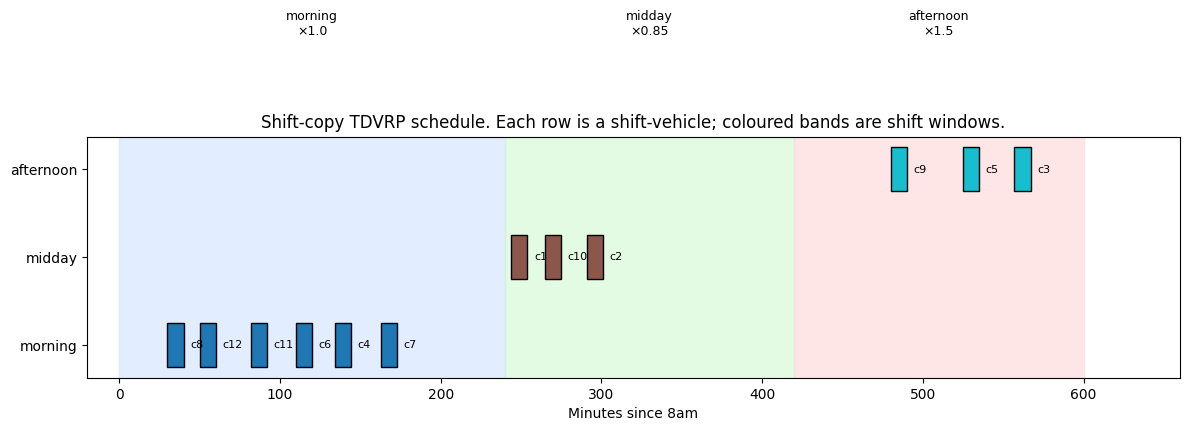

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
shift_colors = ["#cfe2ff", "#d1f7d1", "#ffd6d6"]  # morning, midday, afternoon-rush
for s, c in zip(SHIFTS, shift_colors):
    lo, hi = s["window"]
    ax.axvspan(lo, hi, color=c, alpha=0.6, zorder=0)
    ax.text((lo + hi) / 2, len(result["routes"]) + 0.5,
            f"{s['name']}\n×{s['multiplier']}", ha="center", va="bottom", fontsize=9)

veh_colors = plt.cm.tab10(np.linspace(0, 1, len(SHIFTS)))
for v, (route, shift) in enumerate(zip(result["routes"], SHIFTS)):
    y = v
    for node in route:
        if node == DEPOT or node not in result["arrivals"]:
            continue
        arr = result["arrivals"][node]
        ax.barh(y, SERVICE_TIME, left=arr, color=veh_colors[v], edgecolor="black", height=0.5)
        ax.text(arr + SERVICE_TIME + 4, y, f"c{node}", va="center", fontsize=8)

ax.set_yticks(range(len(SHIFTS)))
ax.set_yticklabels([s["name"] for s in SHIFTS])
ax.set_xlim(-20, HORIZON + 60)
ax.set_xlabel("Minutes since 8am")
ax.set_title("Shift-copy TDVRP schedule. Each row is a shift-vehicle; coloured bands are shift windows.")
plt.tight_layout(); plt.show()

## 5. Caveats and when to reach for something else

**Shift-copy is the right tool when:**

- Traffic patterns are well-described by a small number of bands (rush vs off-peak).
- Each customer's visit can plausibly be assigned to *one* shift (no requirement to span shifts).
- You have enough vehicle capacity per shift, or you're modelling multiple physical trucks per shift by adding more vehicles per band.

**Reach for the time-expanded graph when:**

- A single physical truck's route genuinely spans the morning/afternoon boundary and you need travel times to switch *mid-route*.
- Traffic patterns are smooth (piecewise-linear), not blocky.

**Reach for the soft-penalty approach when:**

- You don't have data for K matrices, but you do know "finishing late is bad." One coefficient, no model surgery.

## Promoting to `vrp_lib`

Next commit adds `solve_tdvrp(shift_travel, shifts, ...)` to `vrp_lib.solver`, plus a test that checks the solver actually routes the morning-only customer through the morning vehicle and the afternoon-only customer through the afternoon vehicle.